# As empresas de Uberlândia (CEMPRE, IBGE)

Quantas empresas a cidade tem, de quais setores, qual o tamanho delas e quando foram fundadas.

Fonte: CEMPRE (Cadastro Central de Empresas) do IBGE, pelas tabelas 9582 e 3421 do SIDRA. O CEMPRE conta empresas e outras organizações com pelo menos um vínculo empregatício no ano, então não inclui MEI sem funcionário nem autônomos. Ano mais recente disponível por município: 2024.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print('ok')

ok


## 2. Carregar os dados

O arquivo `dados/cempre_uberlandia.csv` já tem os cortes da cidade, baixados da API do SIDRA. O passo a passo das consultas está no README da pasta.

In [2]:
df = pd.read_csv('dados/cempre_uberlandia.csv')

totais = df[df['grupo'] == 'total_ano'].copy()
totais['empresas'] = pd.to_numeric(totais['empresas'])
print(totais.to_string(index=False))

    grupo categoria  empresas
total_ano      2022   44336.0
total_ano      2023   48191.0
total_ano      2024   52564.0


## 3. Quantas empresas, e crescendo quanto

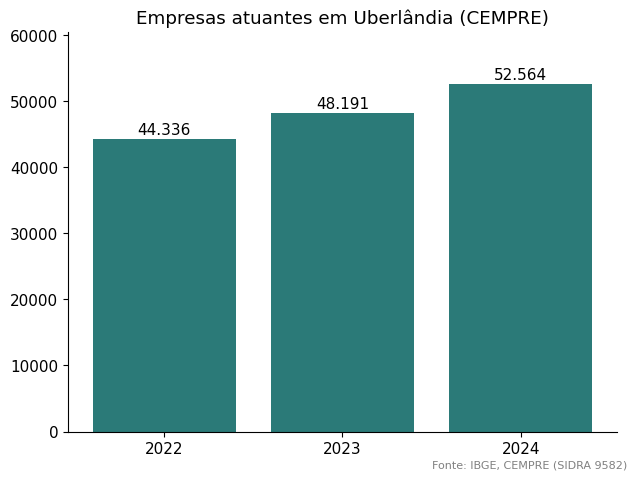

crescimento de 2022 a 2024: 18.6%


In [3]:
fig, ax = plt.subplots()
barras = ax.bar(totais['categoria'], totais['empresas'], color='#2b7a78')
ax.set_title('Empresas atuantes em Uberlândia (CEMPRE)')
for b, v in zip(barras, totais['empresas']):
    ax.text(b.get_x() + b.get_width()/2, v + 700, f'{v:,.0f}'.replace(',', '.'), ha='center')
ax.set_ylim(0, totais['empresas'].max() * 1.15)
fig.text(0.99, 0.01, 'Fonte: IBGE, CEMPRE (SIDRA 9582)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/empresas_total.png', dpi=150, bbox_inches='tight')
plt.show()

cresc = (totais['empresas'].iloc[-1] / totais['empresas'].iloc[0] - 1) * 100
print(f'crescimento de 2022 a 2024: {cresc:.1f}%')

## 4. Quais setores dominam

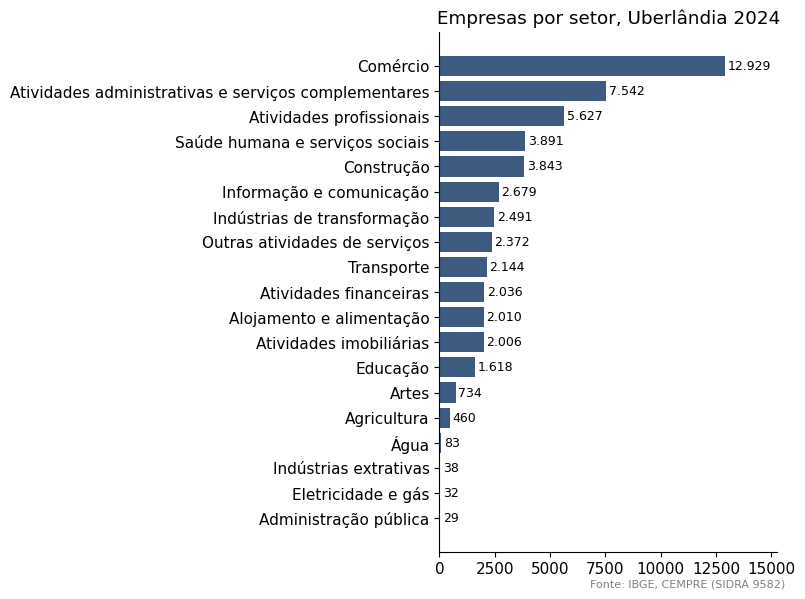

comércio: 12.929 empresas (25% do total)


In [4]:
cnae = df[df['grupo'] == 'setor_cnae'].copy()
cnae['setor'] = cnae['categoria'].str.replace(r'^[A-Z] ', '', regex=True).str.split(';').str[0].str.split(',').str[0]
cnae = cnae.sort_values('empresas')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(cnae['setor'], cnae['empresas'], color='#3d5a80')
for i, v in enumerate(cnae['empresas']):
    ax.text(v + 120, i, f'{v:,.0f}'.replace(',', '.'), va='center', fontsize=9)
ax.set_title('Empresas por setor, Uberlândia 2024')
ax.set_xlim(0, cnae['empresas'].max() * 1.18)
fig.text(0.99, 0.01, 'Fonte: IBGE, CEMPRE (SIDRA 9582)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/empresas_setor.png', dpi=150, bbox_inches='tight')
plt.show()

comercio = cnae[cnae['setor'].str.contains('Comércio')]['empresas'].iloc[0]
total = cnae['empresas'].sum()
print(f'comércio: {comercio:,.0f} empresas ({comercio/total*100:.0f}% do total)'.replace(',', '.'))

## 5. O tamanho das empresas

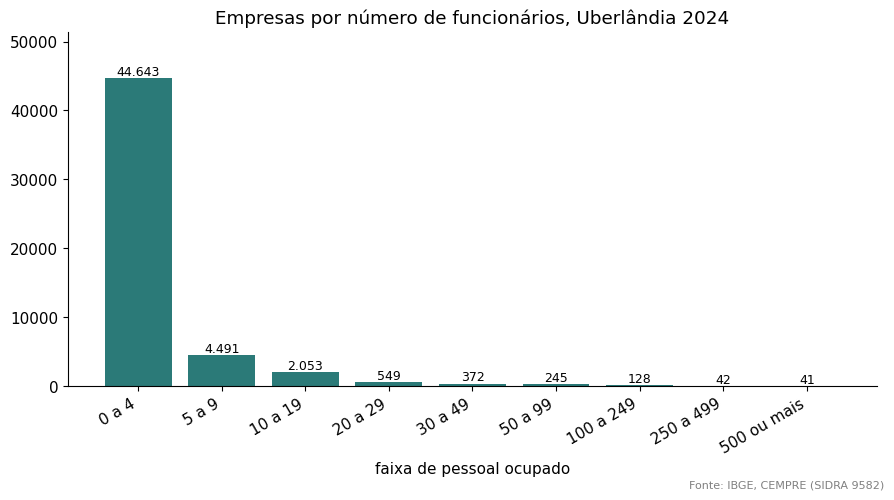

44.643 empresas têm até 4 funcionários (85% do total)
só 41.0 empresas têm 500 ou mais funcionários


In [5]:
ordem = ['0 a 4', '5 a 9', '10 a 19', '20 a 29', '30 a 49', '50 a 99', '100 a 249', '250 a 499', '500 ou mais']
faixas = df[df['grupo'] == 'faixa_funcionarios'].copy()
faixas['categoria'] = pd.Categorical(faixas['categoria'], categories=ordem, ordered=True)
faixas = faixas.sort_values('categoria')

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(faixas['categoria'].astype(str), faixas['empresas'], color='#2b7a78')
ax.set_title('Empresas por número de funcionários, Uberlândia 2024')
for b, v in zip(barras, faixas['empresas']):
    ax.text(b.get_x() + b.get_width()/2, v + 400, f'{v:,.0f}'.replace(',', '.'), ha='center', fontsize=9)
ax.set_ylim(0, faixas['empresas'].max() * 1.15)
ax.set_xlabel('faixa de pessoal ocupado')
plt.xticks(rotation=30, ha='right')
fig.text(0.99, 0.01, 'Fonte: IBGE, CEMPRE (SIDRA 9582)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/empresas_porte.png', dpi=150, bbox_inches='tight')
plt.show()

micro = faixas[faixas['categoria'] == '0 a 4']['empresas'].iloc[0]
total_f = faixas['empresas'].sum()
print(f'{micro:,.0f} empresas têm até 4 funcionários ({micro/total_f*100:.0f}% do total)'.replace(',', '.'))
grandes = faixas[faixas['categoria'] == '500 ou mais']['empresas'].iloc[0]
print(f'só {grandes} empresas têm 500 ou mais funcionários')

## 6. Quando elas nasceram

O CEMPRE registra o ano de fundação de cada empresa ativa. Somando as fundadas de 2020 para cá dá para ver o fôlego recente.

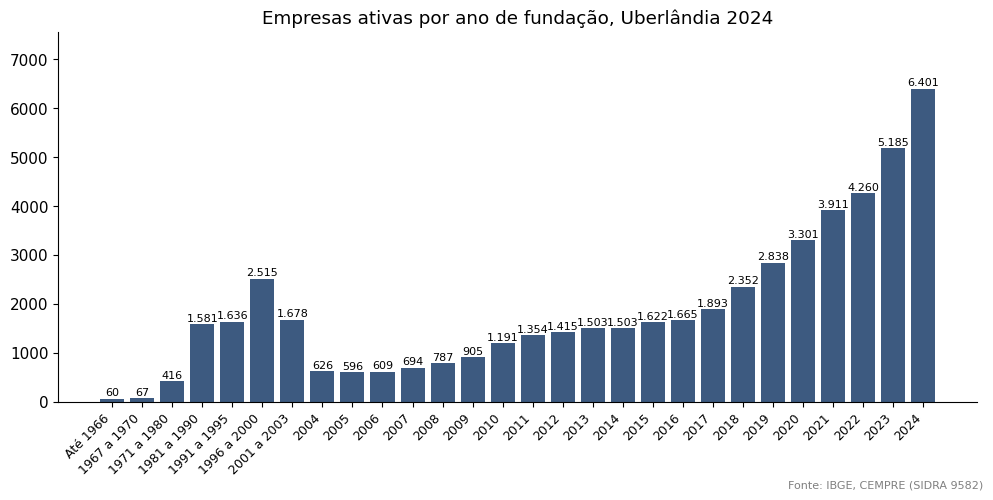

23.058 empresas ativas foram fundadas de 2020 para cá (44% do total)


In [6]:
fund = df[df['grupo'] == 'ano_fundacao'].copy()
fund['rotulo'] = fund['categoria']
fund['ordem'] = fund['categoria'].str.extract(r'(\d{4})').astype(int)
fund = fund.sort_values('ordem')

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(fund['rotulo'], fund['empresas'], color='#3d5a80')
ax.set_title('Empresas ativas por ano de fundação, Uberlândia 2024')
plt.xticks(rotation=45, ha='right', fontsize=9)
for b, v in zip(barras, fund['empresas']):
    ax.text(b.get_x() + b.get_width()/2, v + 60, f'{v:,.0f}'.replace(',', '.'), ha='center', fontsize=8)
ax.set_ylim(0, fund['empresas'].max() * 1.18)
fig.text(0.99, 0.01, 'Fonte: IBGE, CEMPRE (SIDRA 9582)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/empresas_fundacao.png', dpi=150, bbox_inches='tight')
plt.show()

recentes = fund[fund['rotulo'].isin(['2020','2021','2022','2023','2024'])]['empresas'].sum()
print(f'{recentes:,.0f} empresas ativas foram fundadas de 2020 para cá ({recentes/52564*100:.0f}% do total)'.replace(',', '.'))

## 7. Quem trabalha nessas empresas

A tabela 3421 do mesmo cadastro mostra o pessoal ocupado e o salário médio. Ela está publicada até 2021, então os números abaixo são daquele ano (a série de empresas acima vai até 2024; as duas tabelas ainda não têm o mesmo ano final).

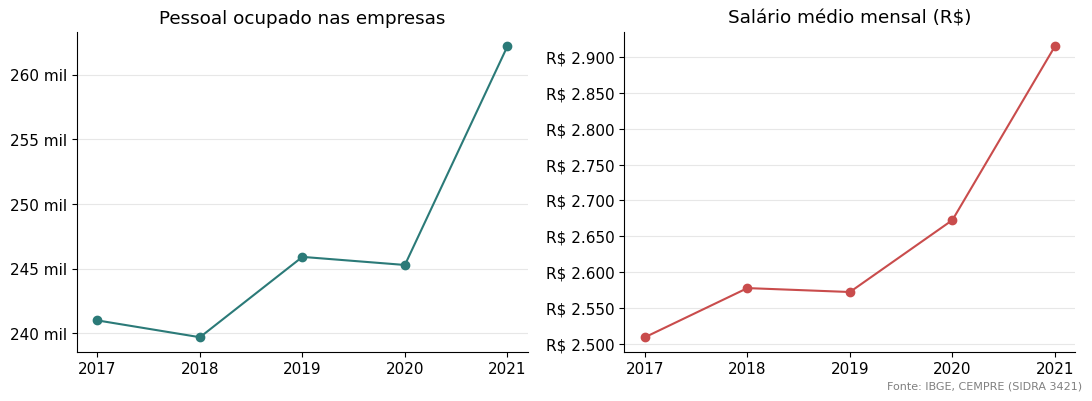

pessoal ocupado em 2021: 262.189
salário médio em 2021: R$ 2.914,92


In [7]:
ocup = df[df['grupo'] == 'pessoal_ocupado'].copy()
ocup['empresas'] = pd.to_numeric(ocup['empresas'])
sal = df[df['grupo'] == 'salario_medio'].copy()
sal['empresas'] = pd.to_numeric(sal['empresas'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ocup['categoria'], ocup['empresas'], marker='o', color='#2b7a78')
axes[0].set_title('Pessoal ocupado nas empresas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f} mil'))
axes[1].plot(sal['categoria'], sal['empresas'], marker='o', color='#c94c4c')
axes[1].set_title('Salário médio mensal (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'.replace(',', '.')))
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
fig.text(0.99, 0.01, 'Fonte: IBGE, CEMPRE (SIDRA 3421)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/empresas_ocupacao_salario.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"pessoal ocupado em 2021: {ocup['empresas'].iloc[-1]:,.0f}".replace(',', '.'))
print(f"salário médio em 2021: R$ {sal['empresas'].iloc[-1]:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

## 8. O que eu tiro disso

Uberlândia tinha **52.564 empresas ativas em 2024**, um crescimento de 18,5% em dois anos (eram 44.336 em 2022). Três coisas me chamaram atenção:

1. **É uma cidade de comércio e serviços.** Só o comércio responde por 12.929 empresas, uma em cada quatro. Somando serviços administrativos (7.542) e profissionais (5.627), os serviços dominam o mapa.
2. **É uma cidade de empresa pequena.** 85% das empresas têm até 4 funcionários (44.643). Só 41 empresas no município inteiro passam de 500 funcionários.
3. **É uma cidade que abre empresa.** 23.058 das empresas ativas foram fundadas de 2020 para cá, ou seja, 44% do estoque atual tem 5 anos ou menos. Em 2024 sozinho nasceram 6.401 que seguem ativas.

Ressalva importante: o CEMPRE conta empresas com vínculo empregatício. MEI sem funcionário e autônomos ficam de fora, então o número real de negócios na cidade é maior.